In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
df.head(10)

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
1949-06-01,135
1949-07-01,148
1949-08-01,148
1949-09-01,136


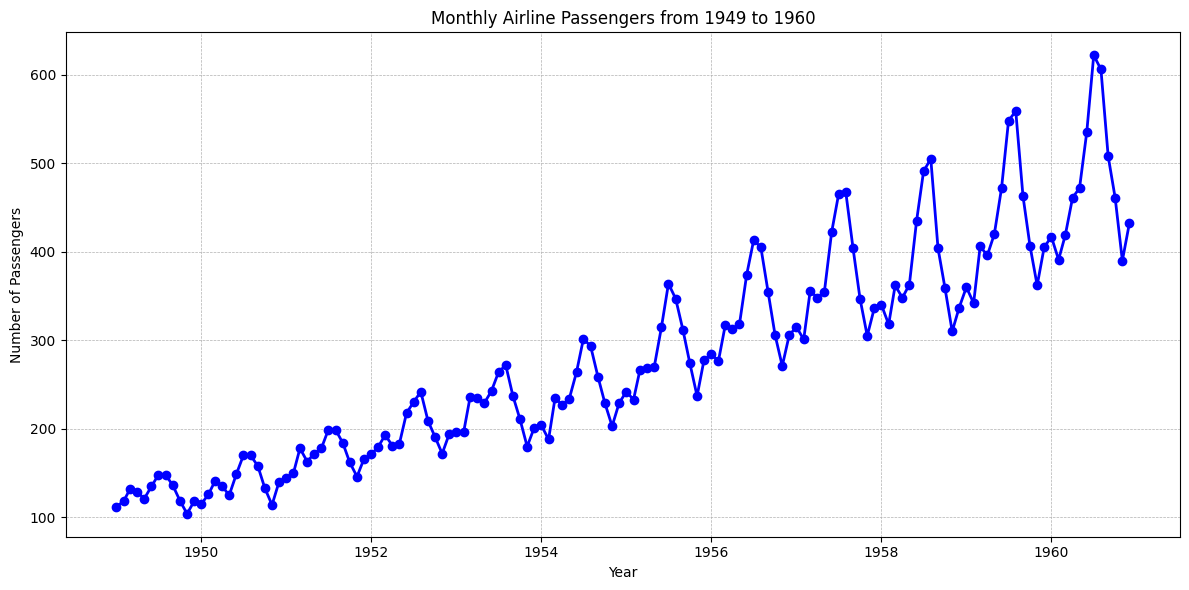

In [3]:
# Creating a line plot
plt.figure(figsize=(12,6))
plt.plot(df, color='blue', marker='o', linestyle='-', linewidth=2, markersize=6)
plt.title('Monthly Airline Passengers from 1949 to 1960')
plt.ylabel('Number of Passengers')
plt.xlabel('Year')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

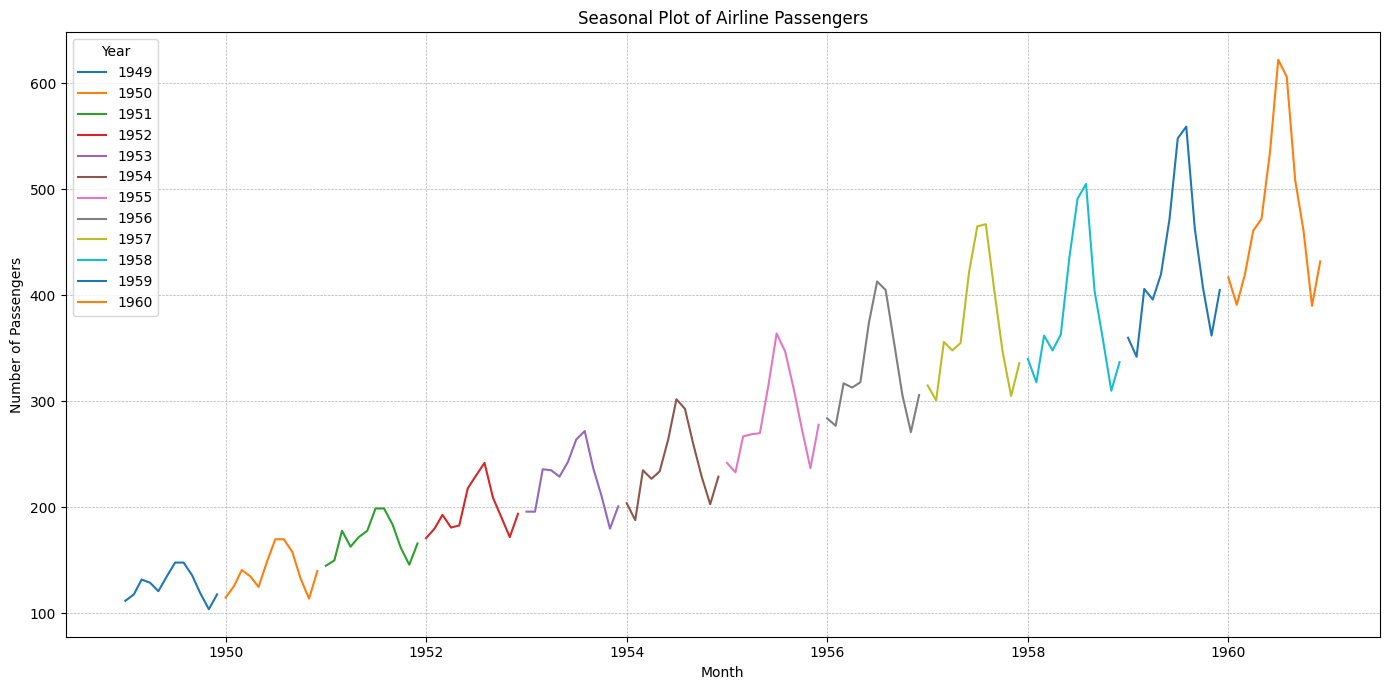

In [4]:
# Extract years from the data
years = df.index.year.unique()

# Plotting each year as its own line
plt.figure(figsize=(14,7))
for year in years:
    subset = df[df.index.year == year]
    plt.plot(subset['Passengers'], label=year)

plt.title('Seasonal Plot of Airline Passengers')
plt.ylabel('Number of Passengers')
plt.xlabel('Month')
plt.legend(title='Year')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

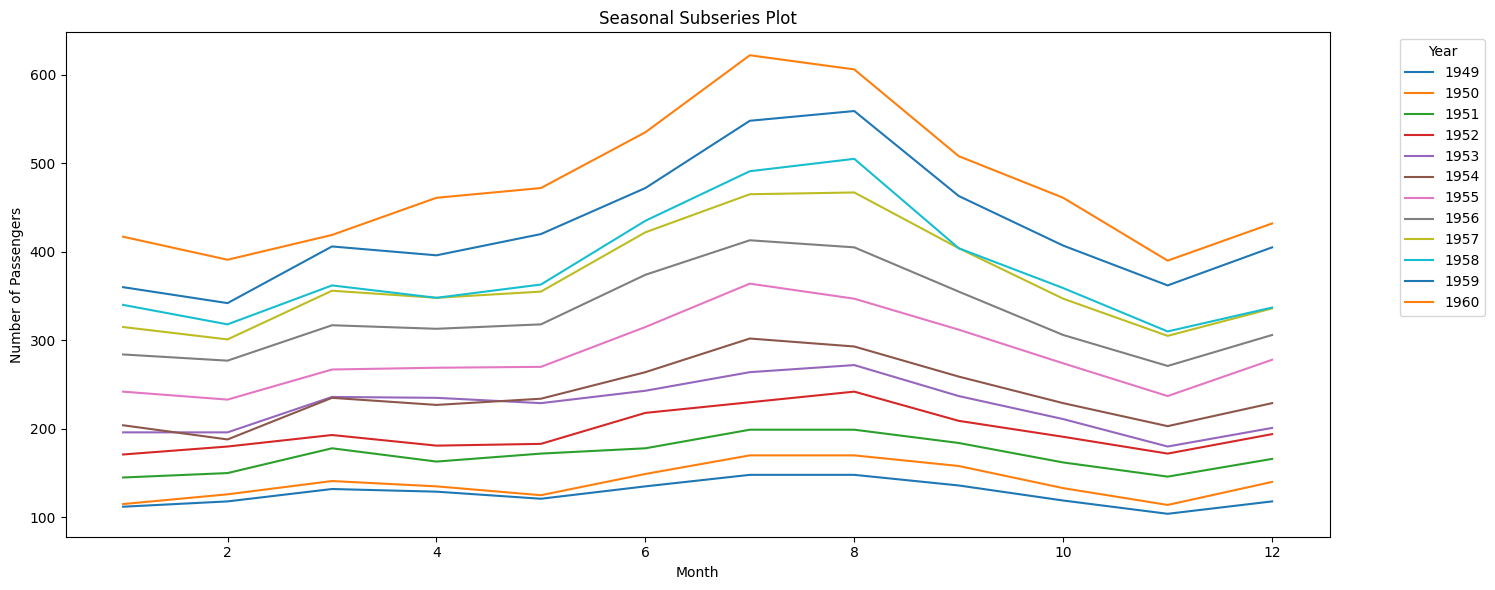

In [5]:
# Extract month and year from the date
df['Year'] = df.index.year
df['month'] = df.index.month

# Pivot table so that we get years on the x-axis and months on the y-axis
table = pd.pivot_table(df, values='Passengers', index=['month'], columns=['Year'], aggfunc='sum')

# Plot the seasonal subseries
fig, ax = plt.subplots(figsize=(15, 6))
table.plot(ax=ax, kind='line', legend=True)
ax.set_xlabel('Month')
ax.set_ylabel('Number of Passengers')
ax.set_title('Seasonal Subseries Plot')
ax.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

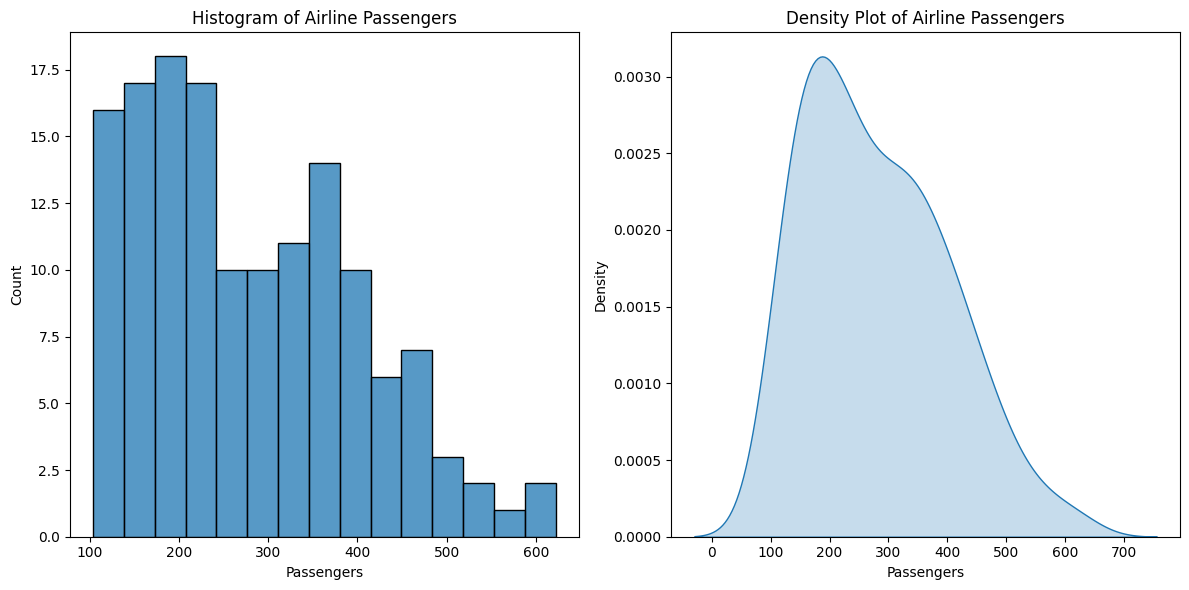

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')

# Histogram
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.histplot(df['Passengers'], bins=15, kde=False)
plt.title('Histogram of Airline Passengers')

# Density plot (KDE)
plt.subplot(1,2,2)
sns.kdeplot(df['Passengers'], fill=True)
plt.title('Density Plot of Airline Passengers')

plt.tight_layout()
plt.show()


## Excercise 1

### Use the Sunspots dataset (https://www.kaggle.com/datasets/robervalt/sunspots) to demonstrate basic concepts of time series.

            Unnamed: 0  Monthly Mean Total Sunspot Number
Date                                                     
1749-01-31           0                               96.7
1749-02-28           1                              104.3
1749-03-31           2                              116.7
1749-04-30           3                               92.8
1749-05-31           4                              141.7
        Unnamed: 0  Monthly Mean Total Sunspot Number
count  3265.000000                        3265.000000
mean   1632.000000                          81.778775
std     942.668641                          67.889277
min       0.000000                           0.000000
25%     816.000000                          23.900000
50%    1632.000000                          67.200000
75%    2448.000000                         122.500000
max    3264.000000                         398.200000


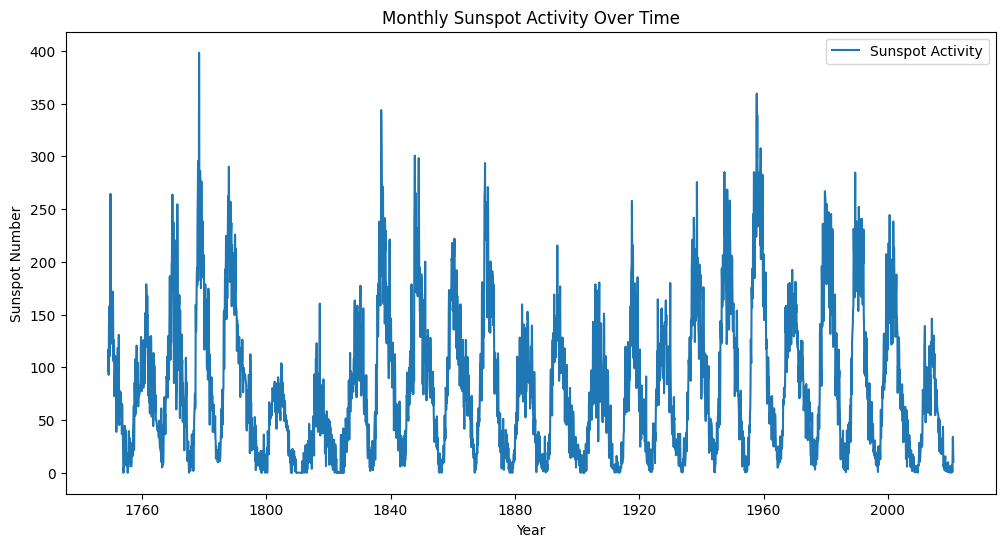

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


                                       SARIMAX Results                                       
Dep. Variable:     Monthly Mean Total Sunspot Number   No. Observations:                 2612
Model:                                ARIMA(5, 1, 0)   Log Likelihood              -12175.313
Date:                               Mon, 28 Oct 2024   AIC                          24362.626
Time:                                       04:26:11   BIC                          24397.830
Sample:                                   01-31-1749   HQIC                         24375.378
                                        - 08-31-1966                                         
Covariance Type:                                 opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4160      0.015    -28.068      0.000      -0.445      -0.387
ar.L2      

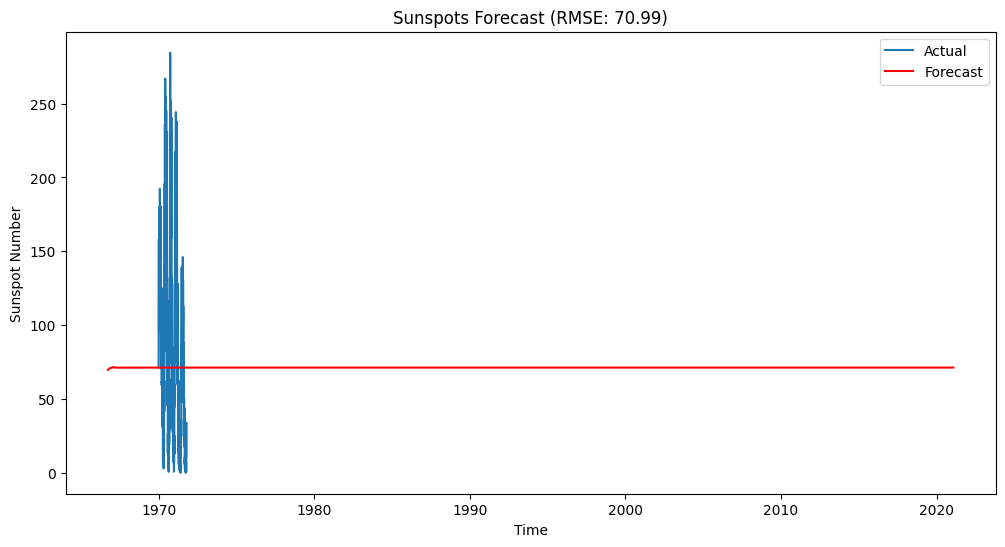

In [16]:
# Exercise 1: Sunspots Dataset

# Step 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np

# Step 2: Load Dataset
url = "https://www.kaggle.com/datasets/robervalt/sunspots"
df_sunspots = pd.read_csv('Sunspots.csv')
df_sunspots['Date'] = pd.to_datetime(df_sunspots['Date'])
df_sunspots.set_index('Date', inplace=True)

# Step 3: Data Exploration
print(df_sunspots.head())
print(df_sunspots.describe())

# Step 4: Data Visualization
plt.figure(figsize=(12, 6))
plt.plot(df_sunspots['Monthly Mean Total Sunspot Number'], label='Sunspot Activity')
plt.title('Monthly Sunspot Activity Over Time')
plt.xlabel('Year')
plt.ylabel('Sunspot Number')
plt.legend()
plt.show()

# Step 5: Time Series Modeling
# Using ARIMA model as a basic example
train_data = df_sunspots['Monthly Mean Total Sunspot Number'][:int(len(df_sunspots) * 0.8)]
test_data = df_sunspots['Monthly Mean Total Sunspot Number'][int(len(df_sunspots) * 0.8):]

model = ARIMA(train_data, order=(5, 1, 0))  # ARIMA order can be adjusted based on data analysis
model_fit = model.fit()
print(model_fit.summary())

# Forecasting
forecast = model_fit.forecast(steps=len(test_data))
test_data = test_data.reset_index(drop=True)
forecast_error = np.sqrt(mean_squared_error(test_data, forecast))

# Plotting forecast vs. actual
plt.figure(figsize=(12, 6))
plt.plot(test_data, label='Actual')
plt.plot(forecast, color='red', label='Forecast')
plt.title(f'Sunspots Forecast (RMSE: {forecast_error:.2f})')
plt.xlabel('Time')
plt.ylabel('Sunspot Number')
plt.legend()
plt.show()


## Excercise 2

### Use the Unemployment in America dataset (https://www.kaggle.com/datasets/justin2028/unemployment-in-america-per-us-state) to demonstrate basic concepts of time series.

Columns in dataset: Index(['FIPS Code', 'State/Area', 'Year', 'Month',
       'Total Civilian Non-Institutional Population in State/Area',
       'Total Civilian Labor Force in State/Area',
       'Percent (%) of State/Area's Population',
       'Total Employment in State/Area',
       'Percent (%) of Labor Force Employed in State/Area',
       'Total Unemployment in State/Area',
       'Percent (%) of Labor Force Unemployed in State/Area'],
      dtype='object')
   FIPS Code  State/Area  Year  Month  \
0          6  California  1976      1   
1          6  California  1976      2   
2          6  California  1976      3   
3          6  California  1976      4   
4          6  California  1976      5   

  Total Civilian Non-Institutional Population in State/Area  \
0                                      15,621,000             
1                                      15,657,000             
2                                      15,694,000             
3                                

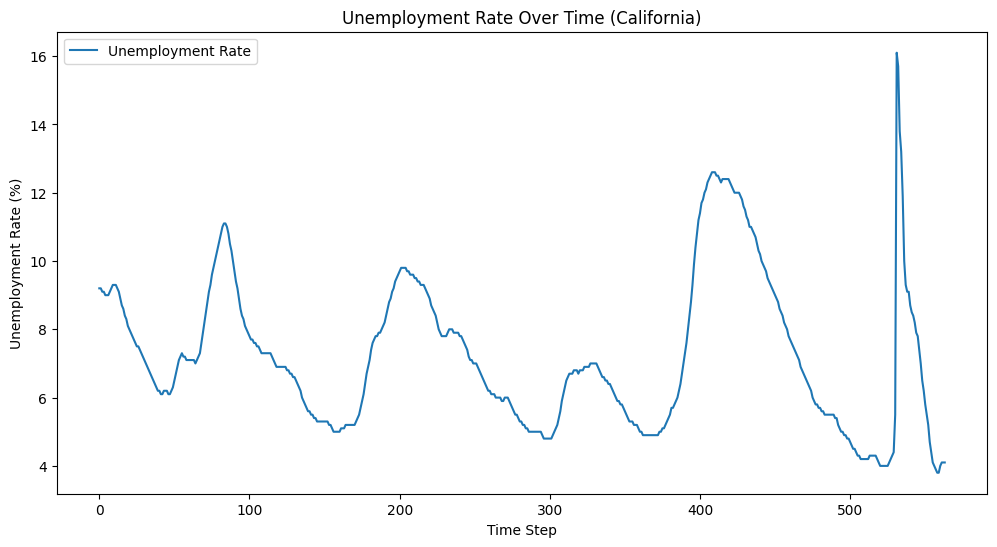

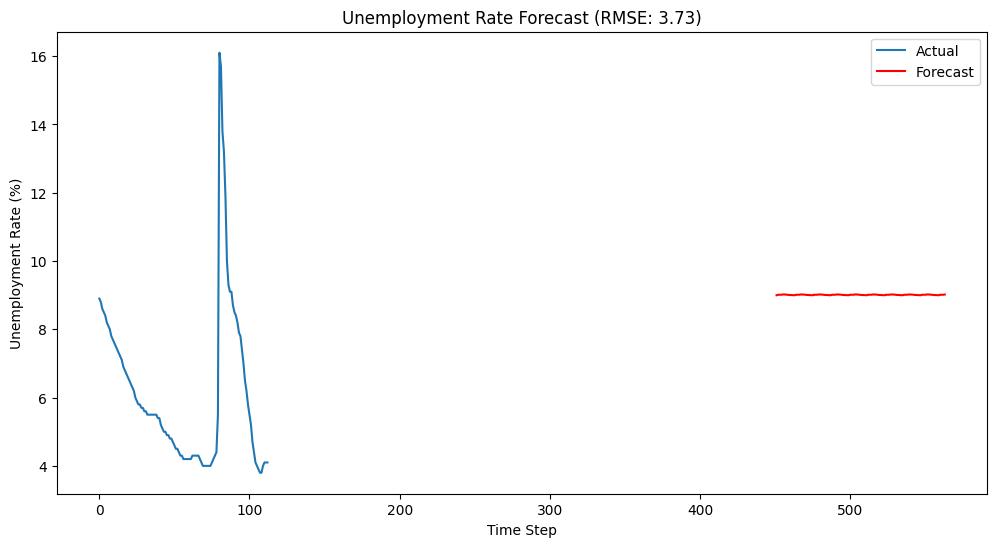

In [21]:
# Exercise 2: Unemployment Dataset

# Step 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error
import numpy as np

# Step 2: Load Dataset
url = "https://www.kaggle.com/datasets/justin2028/unemployment-in-america-per-us-state"
df_unemployment = pd.read_csv('Unemployment in America Per US State.csv')

# Check available columns
print("Columns in dataset:", df_unemployment.columns)

# Ensure necessary columns exist
if 'State/Area' in df_unemployment.columns and 'Percent (%) of Labor Force Unemployed in State/Area' in df_unemployment.columns:
    # Filter for a single state (e.g., California) for time series analysis
    df_unemployment = df_unemployment[df_unemployment['State/Area'] == 'California']
else:
    raise KeyError("The dataset does not contain the expected 'State/Area' or 'Percent (%) of Labor Force Unemployed in State/Area' columns.")

# Reset the index to use a sequential integer index for time steps
df_unemployment.reset_index(drop=True, inplace=True)

# Step 3: Data Exploration
print(df_unemployment.head())
print(df_unemployment.describe())

# Step 4: Data Visualization
plt.figure(figsize=(12, 6))
plt.plot(df_unemployment['Percent (%) of Labor Force Unemployed in State/Area'], label='Unemployment Rate')
plt.title('Unemployment Rate Over Time (California)')
plt.xlabel('Time Step')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.show()

# Step 5: Time Series Modeling
# Using Exponential Smoothing model as a basic example
train_data = df_unemployment['Percent (%) of Labor Force Unemployed in State/Area'][:int(len(df_unemployment) * 0.8)]
test_data = df_unemployment['Percent (%) of Labor Force Unemployed in State/Area'][int(len(df_unemployment) * 0.8):]

model = ExponentialSmoothing(train_data, seasonal='add', seasonal_periods=12)
model_fit = model.fit()
forecast = model_fit.forecast(steps=len(test_data))

# Calculate and print RMSE
forecast_error = np.sqrt(mean_squared_error(test_data, forecast))

# Plotting forecast vs. actual
plt.figure(figsize=(12, 6))
plt.plot(test_data.reset_index(drop=True), label='Actual')
plt.plot(forecast, color='red', label='Forecast')
plt.title(f'Unemployment Rate Forecast (RMSE: {forecast_error:.2f})')
plt.xlabel('Time Step')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.show()